# Hotel Booking Cancellation Prediction

This notebook trains a machine learning model to predict whether a hotel booking will be canceled (`is_canceled`) using `data/hotel_bookings.csv`.


In [1]:
import os
import warnings

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import joblib

warnings.filterwarnings("ignore")

DATA_PATH = os.path.join("data", "hotel_bookings.csv")
RANDOM_STATE = 42
TEST_SIZE = 0.2

df = pd.read_csv(DATA_PATH)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [2]:
# Basic dataset overview
print("Shape:", df.shape)
print("Columns:", len(df.columns))

# Target distribution
print("\nTarget distribution (is_canceled):")
print(df["is_canceled"].value_counts(dropna=False))
print("\nTarget rate:")
print((df["is_canceled"].value_counts(normalize=True) * 100).round(2).astype(str) + "%")

# Missing values (top 15)
na_counts = df.isna().sum().sort_values(ascending=False)
print("\nTop missing values:")
print(na_counts[na_counts > 0].head(15))

# Quick type summary
print("\nDtypes:")
print(df.dtypes.value_counts())

Shape: (119390, 32)
Columns: 32

Target distribution (is_canceled):
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Target rate:
is_canceled
0    62.96%
1    37.04%
Name: proportion, dtype: object

Top missing values:
company     112593
agent        16340
country        488
children         4
dtype: int64

Dtypes:
int64      16
object     12
float64     4
Name: count, dtype: int64


In [3]:

df_fe = df.copy()

# Total nights and party size (adjusted to merge adults, children, babies into person)
df_fe["total_nights"] = df_fe["stays_in_weekend_nights"].fillna(0) + df_fe["stays_in_week_nights"].fillna(0)
df_fe["person"] = (
    df_fe["adults"].fillna(0)
    + df_fe["children"].fillna(0)
    + df_fe["babies"].fillna(0)
)

# Arrival month as categorical (already string), but make sure it's clean
if "arrival_date_month" in df_fe.columns:
    df_fe["arrival_date_month"] = df_fe["arrival_date_month"].astype(str)

# Drop columns that are post-booking outcomes / leakage for cancellation prediction
LEAKAGE_COLS = [
    "reservation_status",
    "reservation_status_date",
]
for c in LEAKAGE_COLS:
    if c in df_fe.columns:
        df_fe = df_fe.drop(columns=[c])

# Drop unnecessary columns to improve model accuracy and reduce noise
UNNECESSARY_COLS = [
    "total_of_special_requests",
    "customer_type",
    "company",
    "agent",
    "deposit_type",
    "country",
    "children",
    "babies",
    "adults",  # merged into person
    "required_car_parking_spaces",
    "adr",
    "days_in_waiting_list",
    "booking_changes",
    "assigned_room_type",
    "reserved_room_type",
    "meal",
    "hotel",  # Low importance, simplify by removing
    "is_repeated_guest",  # Low feature importance
    "previous_bookings_not_canceled",  # Low feature importance
    "arrival_date_year",  # Low feature importance
]
for c in UNNECESSARY_COLS:
    if c in df_fe.columns:
        df_fe = df_fe.drop(columns=[c])

# Filter dataset to remove outliers and improve predictive accuracy (e.g., extreme lead times)
df_fe = df_fe[df_fe['lead_time'] <= 365]  # Remove bookings with lead time > 1 year as outliers
df_fe = df_fe[df_fe['person'] > 0]  # Remove bookings with no persons
df_fe = df_fe[df_fe['total_nights'] > 0]  # Remove bookings with no nights

# Define target and features
y = df_fe["is_canceled"].astype(int)
X = df_fe.drop(columns=["is_canceled"])

In [4]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Print updated dataset info
print("Dataset after cleaning and filtering:")
print(f"Shape: {df_fe.shape}")
print(f"Remaining columns: {list(df_fe.columns)}")
print("Train:", X_train.shape, "Test:", X_test.shape)

Dataset after cleaning and filtering:
Shape: (115421, 12)
Remaining columns: ['is_canceled', 'lead_time', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'market_segment', 'distribution_channel', 'previous_cancellations', 'total_nights', 'person']
Train: (92336, 11) Test: (23085, 11)


In [5]:
# Preprocessing: numeric vs categorical
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 8
Categorical features: 3


In [6]:
# Baseline model: Logistic Regression
log_reg = LogisticRegression(max_iter=2000, class_weight="balanced")

log_reg_clf = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", log_reg),
    ]
)

log_reg_clf.fit(X_train, y_train)

y_pred_lr = log_reg_clf.predict(X_test)
y_proba_lr = log_reg_clf.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr, digits=4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_lr), 4))

Logistic Regression
              precision    recall  f1-score   support

           0     0.7561    0.7010    0.7275     14675
           1     0.5371    0.6055    0.5693      8410

    accuracy                         0.6662     23085
   macro avg     0.6466    0.6532    0.6484     23085
weighted avg     0.6763    0.6662    0.6699     23085

ROC-AUC: 0.7178


In [7]:
# Stronger model: Random Forest
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample",
)

rf_clf = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", rf),
    ]
)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

print("Random Forest")
print(classification_report(y_test, y_pred_rf, digits=4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 4))

Random Forest
              precision    recall  f1-score   support

           0     0.8275    0.8701    0.8483     14675
           1     0.7510    0.6835    0.7156      8410

    accuracy                         0.8021     23085
   macro avg     0.7892    0.7768    0.7820     23085
weighted avg     0.7996    0.8021    0.8000     23085

ROC-AUC: 0.8669


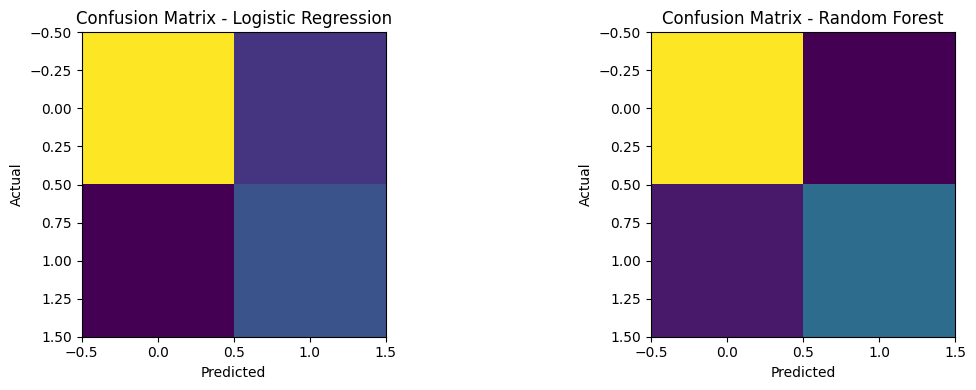

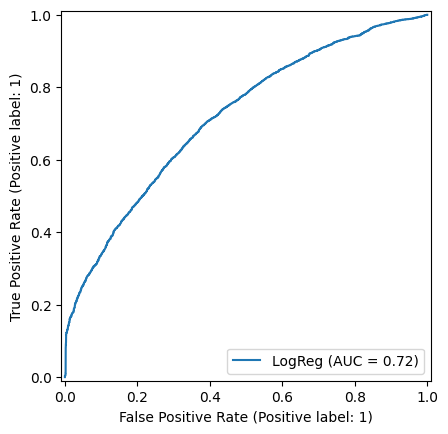

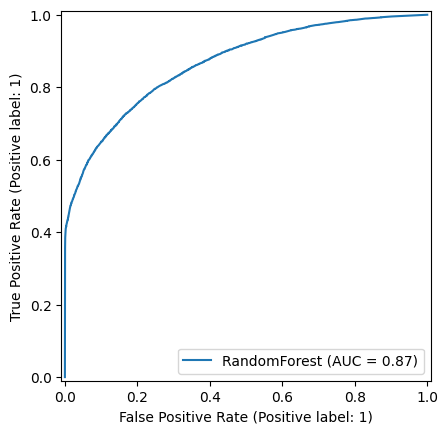

In [8]:
# Confusion matrices and ROC curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

axes[0].imshow(cm_lr)
axes[0].set_title("Confusion Matrix - Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

axes[1].imshow(cm_rf)
axes[1].set_title("Confusion Matrix - Random Forest")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba_lr, name="LogReg")
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name="RandomForest")
plt.show()

Top 20 aggregated feature importances (Random Forest):
lead_time                    0.389327
arrival_date_day_of_month    0.163373
arrival_date_week_number     0.091401
arrival                      0.054276
market                       0.054125
total_nights                 0.050964
person                       0.048931
previous_cancellations       0.048826
stays_in_week_nights         0.046202
stays_in_weekend_nights      0.028300
distribution                 0.024274
dtype: float64


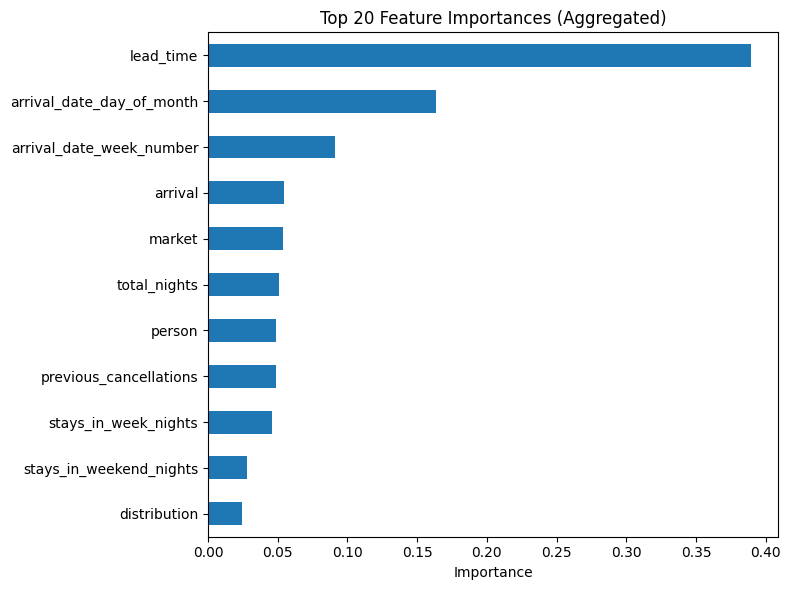

In [9]:
# Feature importance (Random Forest) - aggregated to original features

preprocessor_fitted = rf_clf.named_steps["preprocess"]
rf_model = rf_clf.named_steps["model"]

# Get transformed feature names
num_names = numeric_features
cat_encoder = preprocessor_fitted.named_transformers_["cat"].named_steps["onehot"]
cat_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
feature_names = num_names + cat_names

importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

# Aggregate one-hot categories back to their original column names
agg = {}
for name, val in importances.items():
    if name in numeric_features:
        base = name
    else:
        # onehot naming: col_value
        base = name.split("_")[0]
    agg[base] = agg.get(base, 0.0) + float(val)

agg_importances = pd.Series(agg).sort_values(ascending=False)

print("Top 20 aggregated feature importances (Random Forest):")
print(agg_importances.head(20))

ax = agg_importances.head(20).sort_values().plot(kind="barh", figsize=(8, 6), title="Top 20 Feature Importances (Aggregated)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

In [10]:
# Save the best model pipeline (choose by ROC-AUC)

results = {
    "log_reg": roc_auc_score(y_test, y_proba_lr),
    "random_forest": roc_auc_score(y_test, y_proba_rf),
}

best_name = max(results, key=results.get)
best_auc = results[best_name]

best_model = log_reg_clf if best_name == "log_reg" else rf_clf

print("Best model:", best_name, "ROC-AUC:", round(best_auc, 4))

os.makedirs("artifacts", exist_ok=True)
joblib.dump(best_model, os.path.join("artifacts", "hotel_cancellation_model.joblib"))

print("Saved to:", os.path.join("artifacts", "hotel_cancellation_model.joblib"))

Best model: random_forest ROC-AUC: 0.8669
Saved to: artifacts\hotel_cancellation_model.joblib


In [11]:
# Hyperparameter tuning: Random Forest (standalone + fast)
# This cell is written to be runnable even after a kernel restart.
# It will (re)load the dataset, rebuild preprocessing + baseline features, and run a small randomized search.

import os

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier


DATA_PATH = os.path.join("data", "hotel_bookings.csv")
RANDOM_STATE = 42
TEST_SIZE = 0.2

# Load + feature engineering (same as earlier in notebook)
df = pd.read_csv(DATA_PATH)

df_fe = df.copy()

df_fe["total_nights"] = df_fe["stays_in_weekend_nights"].fillna(0) + df_fe["stays_in_week_nights"].fillna(0)
df_fe["person"] = (
    df_fe["adults"].fillna(0)
    + df_fe["children"].fillna(0)
    + df_fe["babies"].fillna(0)
)

if "arrival_date_month" in df_fe.columns:
    df_fe["arrival_date_month"] = df_fe["arrival_date_month"].astype(str)

df_fe = df_fe.drop(columns=["reservation_status", "reservation_status_date"], errors="ignore")

# Drop unnecessary columns
UNNECESSARY_COLS = [
    "total_of_special_requests",
    "customer_type",
    "company",
    "agent",
    "deposit_type",
    "country",
    "children",
    "babies",
    "adults",
    "required_car_parking_spaces",
    "adr",
    "days_in_waiting_list",
    "booking_changes",
    "assigned_room_type",
    "reserved_room_type",
    "meal",
    "hotel",
    "is_repeated_guest",
    "previous_bookings_not_canceled",
    "arrival_date_year",
]
for c in UNNECESSARY_COLS:
    if c in df_fe.columns:
        df_fe = df_fe.drop(columns=[c])

# Filter
df_fe = df_fe[df_fe['lead_time'] <= 365]
df_fe = df_fe[df_fe['person'] > 0]
df_fe = df_fe[df_fe['total_nights'] > 0]

y = df_fe["is_canceled"].astype(int)
X = df_fe.drop(columns=["is_canceled"])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

rf_tuned = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample",
)

rf_tuned_clf = Pipeline(steps=[("preprocess", preprocess), ("model", rf_tuned)])

param_distributions = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [None, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.5],
}

# Fast randomized search: 8 candidates x 3 folds = 24 fits.
search = RandomizedSearchCV(
    rf_tuned_clf,
    param_distributions=param_distributions,
    n_iter=8,
    scoring="roc_auc",
    cv=3,
    n_jobs=1,
    verbose=1,
    random_state=RANDOM_STATE,
)

search.fit(X_train, y_train)

print("Best params:")
print(search.best_params_)
print("Best CV ROC-AUC:", round(search.best_score_, 4))

best_rf_tuned = search.best_estimator_

y_pred_rf_tuned = best_rf_tuned.predict(X_test)
y_proba_rf_tuned = best_rf_tuned.predict_proba(X_test)[:, 1]

print("\nRandom Forest (Tuned)")
print(classification_report(y_test, y_pred_rf_tuned, digits=4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf_tuned), 4))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params:
{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 20}
Best CV ROC-AUC: 0.8582

Random Forest (Tuned)
              precision    recall  f1-score   support

           0     0.8423    0.8099    0.8258     14675
           1     0.6892    0.7353    0.7115      8410

    accuracy                         0.7828     23085
   macro avg     0.7657    0.7726    0.7686     23085
weighted avg     0.7865    0.7828    0.7842     23085

ROC-AUC: 0.8684


In [12]:
# Save the best model pipeline (choose by ROC-AUC)
# This cell is robust to running out-of-order: it will compute missing probabilities if needed.

import os
import joblib

from sklearn.metrics import roc_auc_score

results = {}
models = {}

# Logistic Regression (only if it exists in memory)
if "log_reg_clf" in globals():
    try:
        if "y_proba_lr" not in globals():
            y_proba_lr = log_reg_clf.predict_proba(X_test)[:, 1]
        results["log_reg"] = roc_auc_score(y_test, y_proba_lr)
        models["log_reg"] = log_reg_clf
    except Exception:
        pass

# Baseline Random Forest (only if it exists in memory)
if "rf_clf" in globals():
    try:
        if "y_proba_rf" not in globals():
            y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]
        results["random_forest"] = roc_auc_score(y_test, y_proba_rf)
        models["random_forest"] = rf_clf
    except Exception:
        pass

# Tuned Random Forest (from the tuning cell)
if "best_rf_tuned" in globals():
    try:
        if "y_proba_rf_tuned" not in globals():
            y_proba_rf_tuned = best_rf_tuned.predict_proba(X_test)[:, 1]
        results["random_forest_tuned"] = roc_auc_score(y_test, y_proba_rf_tuned)
        models["random_forest_tuned"] = best_rf_tuned
    except Exception:
        pass

if len(results) == 0:
    raise RuntimeError(
        "No candidate models found. Run at least one model training cell (e.g., Logistic Regression, Random Forest, or the tuning cell) first."
    )

best_name = max(results, key=results.get)
best_auc = results[best_name]
best_model = models[best_name]

print("Best model:", best_name, "ROC-AUC:", round(best_auc, 4))

os.makedirs("artifacts", exist_ok=True)
joblib.dump(best_model, os.path.join("artifacts", "hotel_cancellation_model.joblib"))

print("Saved to:", os.path.join("artifacts", "hotel_cancellation_model.joblib"))


Best model: random_forest_tuned ROC-AUC: 0.8684
Saved to: artifacts\hotel_cancellation_model.joblib


In [13]:
# Threshold tuning (choose an operating point)
# Goal: pick a probability threshold that maximizes F1 for the positive class (cancellation = 1).

import os

import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score


DATA_PATH = os.path.join("data", "hotel_bookings.csv")
ARTIFACT_PATH = os.path.join("artifacts", "hotel_cancellation_model.joblib")
RANDOM_STATE = 42
TEST_SIZE = 0.2

# Load model (the saved best model from the previous cell)
model_for_threshold = best_model if "best_model" in globals() else joblib.load(ARTIFACT_PATH)

# Rebuild test split in a reproducible way (so this cell can run after kernel restart)
df = pd.read_csv(DATA_PATH)

df_fe = df.copy()

df_fe["total_nights"] = df_fe["stays_in_weekend_nights"].fillna(0) + df_fe["stays_in_week_nights"].fillna(0)
df_fe["person"] = (
    df_fe["adults"].fillna(0)
    + df_fe["children"].fillna(0)
    + df_fe["babies"].fillna(0)
)

df_fe = df_fe.drop(columns=["reservation_status", "reservation_status_date"], errors="ignore")

# Drop unnecessary columns
UNNECESSARY_COLS = [
    "total_of_special_requests",
    "customer_type",
    "company",
    "agent",
    "deposit_type",
    "country",
    "children",
    "babies",
    "adults",
    "required_car_parking_spaces",
    "adr",
    "days_in_waiting_list",
    "booking_changes",
    "assigned_room_type",
    "reserved_room_type",
    "meal",
    "hotel",
    "is_repeated_guest",
    "previous_bookings_not_canceled",
    "arrival_date_year",
]
for c in UNNECESSARY_COLS:
    if c in df_fe.columns:
        df_fe = df_fe.drop(columns=[c])

# Filter
df_fe = df_fe[df_fe['lead_time'] <= 365]
df_fe = df_fe[df_fe['person'] > 0]
df_fe = df_fe[df_fe['total_nights'] > 0]

y = df_fe["is_canceled"].astype(int)
X = df_fe.drop(columns=["is_canceled"])

_, X_test_thr, _, y_test_thr = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

y_proba_thr = model_for_threshold.predict_proba(X_test_thr)[:, 1]
auc = roc_auc_score(y_test_thr, y_proba_thr)

# Test thresholds around the optimal range (0.35 to 0.65)
thresholds = np.round(np.arange(0.35, 0.71, 0.05), 2)
rows = []

for t in thresholds:
    y_pred_thr = (y_proba_thr >= t).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(
        y_test_thr, y_pred_thr, average="binary", pos_label=1, zero_division=0
    )
    rows.append({"threshold": float(t), "precision": float(p), "recall": float(r), "f1": float(f1)})

thr_df = pd.DataFrame(rows).sort_values(["f1", "recall"], ascending=False)

RECOMMENDED_THRESHOLD = float(thr_df.iloc[0]["threshold"])

print("ROC-AUC (threshold-independent):", round(float(auc), 4))
print(f"Recommended threshold: {RECOMMENDED_THRESHOLD}")
print(f"At this threshold - Precision: {thr_df.iloc[0]['precision']:.3f}, Recall: {thr_df.iloc[0]['recall']:.3f}, F1: {thr_df.iloc[0]['f1']:.3f}")

# Show only top 5 most relevant thresholds
print("\nTop 5 threshold options:")
print(thr_df.head(5).to_string(index=False))

ROC-AUC (threshold-independent): 0.8684
Recommended threshold: 0.5
At this threshold - Precision: 0.689, Recall: 0.735, F1: 0.711

Top 5 threshold options:
 threshold  precision   recall       f1
      0.50   0.689179 0.735315 0.711500
      0.45   0.631613 0.807729 0.708896
      0.40   0.597154 0.853270 0.702600
      0.55   0.774855 0.633888 0.697319
      0.35   0.575741 0.882164 0.696751


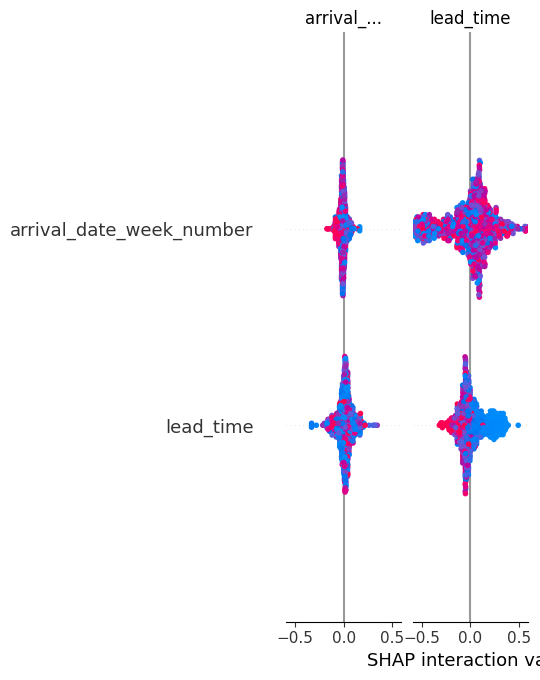

In [14]:
# SHAP explainability (Random Forest tuned)

import numpy as np

try:
    import shap
except ImportError as e:
    raise ImportError("shap is not installed. Install it with: pip install shap") from e

# Prefer the tuned model; fallback to baseline RF
final_pipeline = best_rf_tuned if "best_rf_tuned" in globals() else rf_clf

preprocessor_fitted = final_pipeline.named_steps["preprocess"]
rf_model_fitted = final_pipeline.named_steps["model"]

# Transform test data to numeric matrix
X_test_trans = preprocessor_fitted.transform(X_test)

# Convert sparse -> dense and enforce float dtype (SHAP needs numeric array)
if hasattr(X_test_trans, "toarray"):
    X_test_dense = X_test_trans.toarray()
else:
    X_test_dense = np.asarray(X_test_trans)

X_test_dense = X_test_dense.astype(np.float64)

# Build feature names (numeric + one-hot)
num_names = numeric_features
cat_encoder = preprocessor_fitted.named_transformers_["cat"].named_steps["onehot"]
cat_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
feature_names = num_names + cat_names

# Use a smaller sample for speed in notebooks
n_show = min(1000, X_test_dense.shape[0])
X_show = X_test_dense[:n_show]

explainer = shap.TreeExplainer(rf_model_fitted)
shap_values = explainer.shap_values(X_show)

# Binary classification usually returns [class0, class1]
if isinstance(shap_values, list) and len(shap_values) == 2:
    shap_values_pos = shap_values[1]
    base_val = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
else:
    shap_values_pos = shap_values
    base_val = explainer.expected_value

shap.summary_plot(shap_values_pos, X_show, feature_names=feature_names, show=True)

# Optional: explain one example
idx = 0
try:
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values_pos[idx],
            base_values=base_val,
            data=X_show[idx],
            feature_names=feature_names,
        )
    )
except Exception as _:
    pass
